In [1]:
from pathlib import Path
import colorsys

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import h3

from matplotlib.collections import PolyCollection
from matplotlib.patches import FancyBboxPatch, Rectangle


PROJECT = Path(
    "/Users/mixednutgiftpack/Documents/CASA/OD2017_2023"
)

OUTPUT = PROJECT / "outputs"
FIGURES = PROJECT / "figs"
SHAPES = PROJECT / "2023_OD/Shape"

FIGURES.mkdir(
    parents=True,
    exist_ok=True,
)


H3_RESOLUTION = 8

CLASS_ORDER = [
    "A",
    "B1",
    "B2",
    "C1",
    "C2",
    "D–E",
]

CLASS_COLOURS = {
    "A": "#C5271D",
    "B1": "#3E4570",
    "B2": "#90A5B7",
    "C1": "#8FBFA9",
    "C2": "#B3C06B",
    "D–E": "#2A8F62",
}

INK = "#3A3F42"
INK_LIGHT = "#6B7075"


print(
    f"Output directory: {OUTPUT}\n"
    f"Figure directory: {FIGURES}"
)

Output directory: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/outputs
Figure directory: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs


In [2]:
persons = pd.read_parquet(
    OUTPUT / "persons_2023.parquet"
)

person_hours = pd.read_parquet(
    OUTPUT / "person_hours_2023.parquet"
)

hourly_rhythm = pd.read_csv(
    OUTPUT / "hourly_rhythm_2023.csv",
    index_col="hour",
)


municipalities = (
    gpd.read_file(
        SHAPES / "Municipios_2023.shp"
    )
    .to_crs(4326)
)

zones = (
    gpd.read_file(
        SHAPES / "Zonas_2023.shp"
    )
    .to_crs(4326)
)


print(
    f"Adults: {len(persons):,}\n"
    f"Person-hours: {len(person_hours):,}\n"
    f"Rhythm rows: {len(hourly_rhythm):,}\n"
    f"Municipalities: {len(municipalities):,}\n"
    f"OD zones: {len(zones):,}"
)

Adults: 66,517
Person-hours: 1,596,408
Rhythm rows: 24
Municipalities: 39
OD zones: 527


In [3]:
def hsv_gradient(
    start_colour,
    end_colour,
    name,
):
    """Create a saturated colour gradient in HSV space."""

    h0, s0, v0 = colorsys.rgb_to_hsv(
        *mcolors.to_rgb(start_colour)
    )

    h1, s1, v1 = colorsys.rgb_to_hsv(
        *mcolors.to_rgb(end_colour)
    )

    colours = [
        colorsys.hsv_to_rgb(
            h0 + (h1 - h0) * position,
            s0 + (s1 - s0) * position,
            v0 + (v1 - v0) * position,
        )
        for position in np.linspace(
            0,
            1,
            256,
        )
    ]

    return mcolors.ListedColormap(
        colours,
        name=name,
    )


SAMPLE_CMAP = hsv_gradient(
    "#F1E8C4",
    "#16325C",
    "cream_navy",
)

In [4]:
METRO_BOUNDS = (
    municipalities
    .total_bounds
)


def format_map_axis(
    ax,
    bounds=METRO_BOUNDS,
    padding=0.03,
):
    """Apply a common extent and style to a metropolitan map."""

    minx, miny, maxx, maxy = bounds

    ax.set_xlim(
        minx - padding,
        maxx + padding,
    )

    ax.set_ylim(
        miny - padding,
        maxy + padding,
    )

    ax.set_aspect("equal")
    ax.set_axis_off()


def save_figure(
    fig,
    filename,
    dpi=200,
):
    """Save and display a completed figure."""

    output_path = (
        FIGURES
        / filename
    )

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    print(
        f"Saved: {output_path}"
    )

In [5]:
def add_rounded_colourbar(
    fig,
    cmap,
    vmin,
    vmax,
    ticks,
    label,
):
    """Add a compact rounded vertical colour bar."""

    colourbar_axis = fig.add_axes(
        [
            0.92,
            0.37,
            0.018,
            0.28,
        ]
    )

    gradient = np.linspace(
        1,
        0,
        512,
    ).reshape(-1, 1)

    image = colourbar_axis.imshow(
        gradient,
        aspect="auto",
        cmap=cmap,
        extent=[
            0,
            1,
            0,
            1,
        ],
    )

    clip = FancyBboxPatch(
        (0, 0),
        1,
        1,
        transform=colourbar_axis.transAxes,
        boxstyle="round,pad=0,rounding_size=0.35",
        mutation_aspect=(
            colourbar_axis
            .get_position()
            .width
            / colourbar_axis
            .get_position()
            .height
            * 1.34
        ),
        facecolor="none",
        edgecolor="none",
    )

    colourbar_axis.add_patch(clip)
    image.set_clip_path(clip)

    colourbar_axis.set_xticks([])
    colourbar_axis.set_yticks([])

    for spine in colourbar_axis.spines.values():
        spine.set_visible(False)

    for value in ticks:
        position = (
            (value - vmin)
            / (vmax - vmin)
        )

        colourbar_axis.plot(
            [1.05, 1.16],
            [position, position],
            transform=colourbar_axis.transAxes,
            color="#C9CDD0",
            linewidth=0.6,
            clip_on=False,
        )

        tick_label = (
            f"{value}+"
            if value == vmax
            else str(value)
        )

        colourbar_axis.text(
            1.26,
            position,
            tick_label,
            transform=colourbar_axis.transAxes,
            ha="left",
            va="center",
            fontsize=7.5,
            color=INK_LIGHT,
        )

    colourbar_axis.text(
        0.5,
        1.06,
        label,
        transform=colourbar_axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=INK,
    )

## 2. Adult respondents across OD survey zones

In [6]:
zone_counts = (
    persons
    .dropna(
        subset=["zona"]
    )
    .assign(
        zona=lambda data: (
            data["zona"]
            .astype(int)
        )
    )
    .groupby("zona")
    .size()
    .rename("respondents")
)

zones_plot = zones.merge(
    zone_counts,
    left_on="NumeroZona",
    right_index=True,
    how="left",
    validate="one_to_one",
)

zone_summary = pd.Series({
    "OD zones in shapefile": (
        len(zones_plot)
    ),

    "Zones with sampled adults": (
        zones_plot["respondents"]
        .notna()
        .sum()
    ),

    "Zones without sampled adults": (
        zones_plot["respondents"]
        .isna()
        .sum()
    ),

    "Median respondents per sampled zone": (
        zone_counts.median()
    ),

    "Maximum respondents in one zone": (
        zone_counts.max()
    ),
})

display(
    zone_summary
    .rename("Value")
    .to_frame()
)

,Value
OD zones in shapefile,527.0
Zones with sampled adults,492.0
Zones without sampled adults,35.0
Median respondents per sampled zone,117.0
Maximum respondents in one zone,402.0


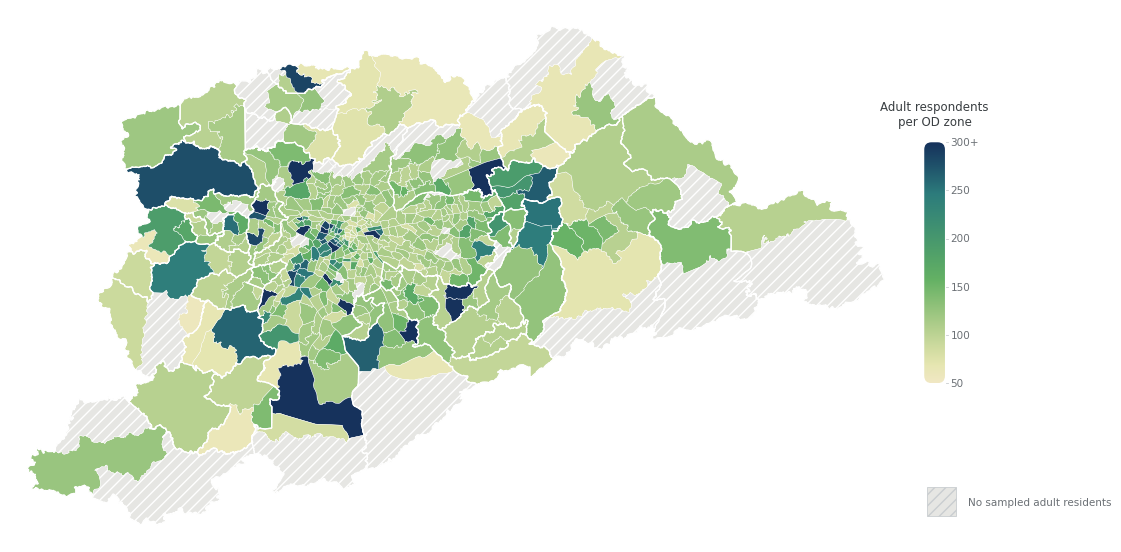

Saved: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/fig_sample_map_2023.png


In [7]:
ZONE_VMIN = 50
ZONE_VMAX = 300

zone_norm = mcolors.Normalize(
    vmin=ZONE_VMIN,
    vmax=ZONE_VMAX,
)

fig, ax = plt.subplots(
    figsize=(11.5, 8.6)
)


# Metropolitan background
municipalities.plot(
    ax=ax,
    facecolor="#F0F0EE",
    edgecolor="none",
    zorder=0,
)


zones_plot.loc[
    zones_plot["respondents"].notna()
].plot(
    ax=ax,
    column="respondents",
    cmap=SAMPLE_CMAP,
    norm=zone_norm,
    edgecolor="white",
    linewidth=0.3,
    zorder=2,
)


zones_plot.loc[
    zones_plot["respondents"].isna()
].plot(
    ax=ax,
    facecolor="#E6E6E3",
    edgecolor="white",
    linewidth=0.3,
    hatch="///",
    zorder=2,
)


municipalities.boundary.plot(
    ax=ax,
    color="white",
    linewidth=0.9,
    zorder=3,
)


format_map_axis(ax)


add_rounded_colourbar(
    fig=fig,
    cmap=SAMPLE_CMAP,
    vmin=ZONE_VMIN,
    vmax=ZONE_VMAX,
    ticks=[
        50,
        100,
        150,
        200,
        250,
        300,
    ],
    label=(
        "Adult respondents\n"
        "per OD zone"
    ),
)


note_x = 0.922
note_y = 0.215

fig.add_artist(
    Rectangle(
        (
            note_x,
            note_y,
        ),
        0.026,
        0.034,
        transform=fig.transFigure,
        facecolor="#E6E6E3",
        edgecolor="#C9CDD0",
        linewidth=0.6,
        hatch="///",
        clip_on=False,
    )
)

fig.text(
    note_x + 0.036,
    note_y + 0.017,
    "No sampled adult residents",
    ha="left",
    va="center",
    fontsize=7.5,
    color=INK_LIGHT,
)


save_figure(
    fig,
    "fig_sample_map_2023.png",
)

## 3. Adult respondents across H3 home cells

In [8]:
hex_counts = (
    persons
    .dropna(
        subset=["hex_home"]
    )
    .groupby("hex_home")
    .size()
    .rename("respondents")
)

hex_summary = pd.Series({
    "Adults with a home H3 cell": (
        persons["hex_home"]
        .notna()
        .sum()
    ),

    "Adults missing a home H3 cell": (
        persons["hex_home"]
        .isna()
        .sum()
    ),

    "Occupied home cells": (
        len(hex_counts)
    ),

    "Median respondents per occupied cell": (
        hex_counts.median()
    ),

    "Maximum respondents in one cell": (
        hex_counts.max()
    ),
})

display(
    hex_summary
    .rename("Value")
    .to_frame()
)

,Value
Adults with a home H3 cell,66517.0
Adults missing a home H3 cell,0.0
Occupied home cells,3172.0
Median respondents per occupied cell,13.0
Maximum respondents in one cell,307.0


In [9]:
metropolitan_region = (
    municipalities.union_all()
    if hasattr(
        municipalities,
        "union_all",
    )
    else municipalities.unary_union
)

all_metropolitan_cells = set(
    h3.geo_to_cells(
        metropolitan_region,
        H3_RESOLUTION,
    )
)

sampled_home_cells = set(
    hex_counts.index
)


all_metropolitan_cells = (
    all_metropolitan_cells
    | sampled_home_cells
)

empty_home_cells = sorted(
    all_metropolitan_cells
    - sampled_home_cells
)

print(
    f"Metropolitan H3 cells: "
    f"{len(all_metropolitan_cells):,}\n"
    f"Cells with sampled adult homes: "
    f"{len(sampled_home_cells):,}\n"
    f"Cells without sampled adult homes: "
    f"{len(empty_home_cells):,}"
)

Metropolitan H3 cells: 10,714
Cells with sampled adult homes: 3,172
Cells without sampled adult homes: 7,542


In [10]:
if hasattr(
    h3,
    "cell_to_boundary",
):
    cell_boundary_function = (
        h3.cell_to_boundary
    )

elif hasattr(
    h3,
    "h3_to_geo_boundary",
):
    cell_boundary_function = (
        h3.h3_to_geo_boundary
    )

else:
    raise AttributeError(
        "The installed H3 package does not provide "
        "a cell-boundary function."
    )


def h3_polygon(cell):
    """
    Convert one H3 cell boundary to longitude–latitude order
    for Matplotlib.
    """

    boundary = (
        cell_boundary_function(cell)
    )

    return [
        (longitude, latitude)
        for latitude, longitude in boundary
    ]
    

In [11]:
empty_hex_polygons = [
    h3_polygon(cell)
    for cell in empty_home_cells
]

sampled_hex_polygons = [
    h3_polygon(cell)
    for cell in hex_counts.index
]

sampled_hex_values = (
    hex_counts
    .to_numpy()
)

print(
    f"Empty polygons prepared: "
    f"{len(empty_hex_polygons):,}\n"
    f"Sampled polygons prepared: "
    f"{len(sampled_hex_polygons):,}"
)

Empty polygons prepared: 7,542
Sampled polygons prepared: 3,172


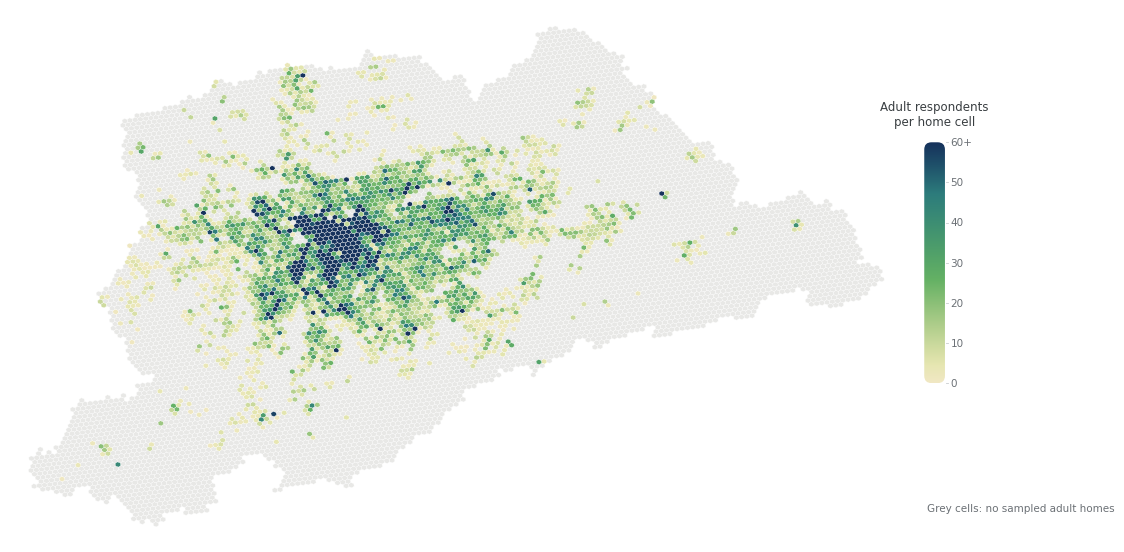

Saved: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/fig_sample_hexmap_2023.png


In [12]:
HEX_VMIN = 0
HEX_VMAX = 60

hex_norm = mcolors.Normalize(
    vmin=HEX_VMIN,
    vmax=HEX_VMAX,
)

fig, ax = plt.subplots(
    figsize=(11.5, 8.6)
)


# Metropolitan H3 cells without sampled homes
ax.add_collection(
    PolyCollection(
        empty_hex_polygons,
        facecolor="#E8E8E6",
        edgecolor="white",
        linewidth=0.25,
        zorder=1,
    )
)


# H3 cells containing sampled adult homes
sampled_collection = PolyCollection(
    sampled_hex_polygons,
    array=np.minimum(
        sampled_hex_values,
        HEX_VMAX,
    ),
    cmap=SAMPLE_CMAP,
    norm=hex_norm,
    edgecolor="white",
    linewidth=0.25,
    zorder=2,
)

ax.add_collection(
    sampled_collection
)


format_map_axis(ax)


add_rounded_colourbar(
    fig=fig,
    cmap=SAMPLE_CMAP,
    vmin=HEX_VMIN,
    vmax=HEX_VMAX,
    ticks=[
        0,
        10,
        20,
        30,
        40,
        50,
        60,
    ],
    label=(
        "Adult respondents\n"
        "per home cell"
    ),
)


fig.text(
    0.922,
    0.225,
    "Grey cells: no sampled adult homes",
    ha="left",
    va="center",
    fontsize=7.5,
    color=INK_LIGHT,
)


save_figure(
    fig,
    "fig_sample_hexmap_2023.png",
)


## 4. Hourly population rhythm

In [13]:
person_hours["home_no_trip"] = np.where(
    ~person_hours["mobile"],
    person_hours["home"],
    0,
)

person_hours["home_mobile"] = np.where(
    person_hours["mobile"],
    person_hours["home"],
    0,
)


RHYTHM_CATEGORIES = [
    "home_no_trip",
    "home_mobile",
    "away",
    "transit",
]


for category in RHYTHM_CATEGORIES:
    person_hours[
        f"weighted_{category}"
    ] = (
        person_hours[category]
        * person_hours["fe_pess"]
    )


weighted_minutes_per_hour = (
    persons["fe_pess"].sum()
    * 60
)


population_rhythm = (
    person_hours
    .groupby("hour")
    [
        [
            f"weighted_{category}"
            for category in RHYTHM_CATEGORIES
        ]
    ]
    .sum()
    .reindex(range(24))
)


population_rhythm.columns = (
    RHYTHM_CATEGORIES
)

population_rhythm = (
    population_rhythm
    / weighted_minutes_per_hour
)


population_rhythm["total"] = (
    population_rhythm[
        RHYTHM_CATEGORIES
    ]
    .sum(axis=1)
)


display(
    (
        population_rhythm
        * 100
    ).style.format("{:.1f}")
)

,home_no_trip,home_mobile,away,transit,total
hour,,,,,
0,40.5,58.1,1.3,0.2,100.0
1,40.5,58.3,1.2,0.1,100.0
2,40.5,58.4,1.0,0.1,100.0
3,40.5,58.5,1.0,0.1,100.0
4,40.5,57.3,1.0,1.2,100.0
5,40.5,53.7,2.0,3.8,100.0
6,40.5,44.9,5.6,9.0,100.0
7,40.5,34.1,15.3,10.1,100.0
8,40.5,27.3,26.5,5.8,100.0


In [14]:
invalid_rhythm_total = (
    population_rhythm["total"]
    .sub(1)
    .abs()
    .gt(1e-9)
)

print(
    f"Hours not summing to 100%: "
    f"{invalid_rhythm_total.sum()}"
)

assert not invalid_rhythm_total.any(), (
    "Some hourly population states do not sum to 100%."
)


weighted_no_trip_share = (
    persons.loc[
        ~persons["mobile"],
        "fe_pess",
    ].sum()
    / persons["fe_pess"].sum()
)

print(
    f"Adults without recorded trips: "
    f"{weighted_no_trip_share:.1%} weighted"
)

Hours not summing to 100%: 0
Adults without recorded trips: 40.5% weighted


In [15]:
class_home_rhythm = (
    person_hours
    .assign(
        weighted_home_minutes=(
            person_hours["home"]
            * person_hours["fe_pess"]
        ),
        weighted_total_minutes=(
            60
            * person_hours["fe_pess"]
        ),
    )
    .groupby(
        [
            "class6",
            "hour",
        ],
        observed=True,
    )
    .agg(
        home_minutes=(
            "weighted_home_minutes",
            "sum",
        ),
        total_minutes=(
            "weighted_total_minutes",
            "sum",
        ),
    )
    .reset_index()
)


class_home_rhythm["home_share"] = (
    class_home_rhythm["home_minutes"]
    / class_home_rhythm["total_minutes"]
)


class_home_wide = (
    class_home_rhythm
    .pivot(
        index="hour",
        columns="class6",
        values="home_share",
    )
    .reindex(
        index=range(24),
        columns=CLASS_ORDER,
    )
)


display(
    (
        class_home_wide
        * 100
    ).style.format("{:.1f}")
)

class6,A,B1,B2,C1,C2,D–E
hour,,,,,,
0,98.9,98.8,98.6,98.2,98.5,99.1
1,99.1,99.1,98.9,98.4,98.7,99.2
2,99.2,99.1,99.0,98.6,98.8,99.3
3,99.3,99.4,99.0,98.7,98.9,99.3
4,99.1,99.0,98.2,97.4,97.2,97.7
5,97.8,97.0,95.1,93.4,92.7,94.2
6,90.4,88.1,86.5,83.9,83.7,87.9
7,77.6,75.7,73.9,72.8,74.6,80.3
8,67.3,66.1,65.5,66.4,69.7,75.9


In [16]:
minimum_home_by_class = pd.DataFrame({
    "minimum_home_share": (
        class_home_wide.min()
        * 100
    ),

    "hour_of_minimum": (
        class_home_wide.idxmin()
    ),
})

minimum_home_by_class = (
    minimum_home_by_class
    .reindex(CLASS_ORDER)
)

display(
    minimum_home_by_class.style.format({
        "minimum_home_share": "{:.1f}%",
        "hour_of_minimum": "{:.0f}:00",
    })
)

,minimum_home_share,hour_of_minimum
class6,,
A,56.1%,11:00
B1,56.3%,11:00
B2,57.7%,11:00
C1,59.0%,13:00
C2,63.1%,13:00
D–E,71.9%,11:00


In [17]:
RHYTHM_COLOURS = {
    "home_no_trip": "#8FBFA9",
    "home_mobile": "#DCE8E3",
    "away": "#90A5B7",
    "transit": "#D3DE9C",
}


RHYTHM_LABELS = {
    "home_no_trip": (
        "At home — no recorded trips "
        f"({weighted_no_trip_share:.1%})"
    ),
    "home_mobile": "At home — mobile adults",
    "away": "Elsewhere in the region",
    "transit": "In transport",
}


# Display the survey day from 04:00 to 03:00
HOUR_ORDER = (
    list(range(4, 24))
    + list(range(0, 4))
)

HOUR_LABELS = [
    f"{hour:02d}"
    for hour in HOUR_ORDER
]

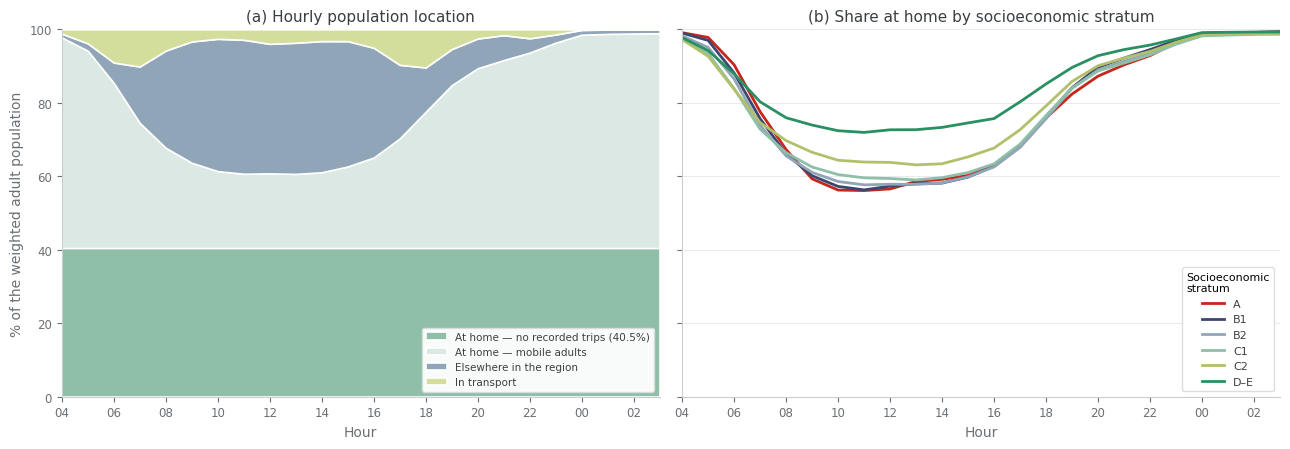

Saved: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/fig_rhythm_2023.png


In [18]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.6),
    sharey=True,
)

fig.patch.set_facecolor("white")

panel_a = population_rhythm.loc[
    HOUR_ORDER,
    RHYTHM_CATEGORIES,
]

axes[0].stackplot(
    range(24),
    panel_a.T.to_numpy() * 100,
    labels=[
        RHYTHM_LABELS[category]
        for category in RHYTHM_CATEGORIES
    ],
    colors=[
        RHYTHM_COLOURS[category]
        for category in RHYTHM_CATEGORIES
    ],
    edgecolor="white",
    linewidth=1.2,
)

axes[0].set_title(
    "(a) Hourly population location",
    color=INK,
    fontsize=11,
)

axes[0].set_ylabel(
    "% of the weighted adult population",
    color=INK_LIGHT,
)

axes[0].legend(
    loc="lower right",
    fontsize=7.5,
    frameon=True,
    framealpha=0.95,
    edgecolor="#D9DCDF",
    labelcolor=INK,
)


for class_label in CLASS_ORDER:
    class_curve = (
        class_home_wide
        .loc[
            HOUR_ORDER,
            class_label,
        ]
        .to_numpy()
        * 100
    )

    axes[1].plot(
        range(24),
        class_curve,
        color=CLASS_COLOURS[class_label],
        linewidth=2,
        label=class_label,
    )

axes[1].set_title(
    "(b) Share at home by socioeconomic stratum",
    color=INK,
    fontsize=11,
)

axes[1].legend(
    title="Socioeconomic\nstratum",
    loc="lower right",
    fontsize=8,
    title_fontsize=8,
    frameon=True,
    framealpha=0.95,
    edgecolor="#D9DCDF",
    labelcolor=INK,
)


tick_positions = list(
    range(0, 24, 2)
)

tick_labels = HOUR_LABELS[::2]

for ax in axes:
    ax.set_xticks(
        tick_positions
    )

    ax.set_xticklabels(
        tick_labels
    )

    ax.set_xlim(
        0,
        23,
    )

    ax.set_ylim(
        0,
        100,
    )

    ax.set_xlabel(
        "Hour",
        color=INK_LIGHT,
    )

    ax.tick_params(
        axis="both",
        colors=INK_LIGHT,
        labelsize=8.5,
    )

    ax.margins(x=0)

    ax.grid(
        axis="y",
        color="#E8EAEC",
        linewidth=0.7,
    )

    ax.set_axisbelow(True)

    for spine in [
        "top",
        "right",
    ]:
        ax.spines[
            spine
        ].set_visible(False)

    for spine in [
        "left",
        "bottom",
    ]:
        ax.spines[
            spine
        ].set_color("#C9CDD1")


fig.tight_layout()


save_figure(
    fig,
    "fig_rhythm_2023.png",
    dpi=200,
)